# English Premier League (EPL) Pythagorean Predictor

## Step 1

In [1]:
# Load the packages

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data. 
# EPL results for the 2017/18 season

EPL18 = pd.read_excel('Assignment Data/Week 1/EPL2017-18.xlsx')
print(EPL18.columns.tolist())

['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']


In [3]:
EPL18

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,20170811,Arsenal,Leicester,4,3,H
1,20170812,Brighton,Man City,0,2,A
2,20170812,Chelsea,Burnley,2,3,A
3,20170812,Crystal Palace,Huddersfield,0,3,A
4,20170812,Everton,Stoke,1,0,H
5,20170812,Southampton,Swansea,0,0,D
6,20170812,Watford,Liverpool,3,3,D
7,20170812,West Brom,Bournemouth,1,0,H
8,20170813,Man United,West Ham,4,0,H
9,20170813,Newcastle,Tottenham,0,2,A


## Step 2

In [4]:
# We will need to know who won the game - which we can tell by who scored more goals, the home team or the visiting teams
# or if the game was tied
# The variable 'hwin' is defined here as equaling 1 if the home team scored more goals, 0.5 for a draw and zero otherwise. 
# The variable 'awin' is defined in a similar way for the away team.
# we also create a 'counter' variable = 1 for each row.

EPL18['hwinvalue']=np.where(EPL18['FTR']=='H',1,np.where(EPL18['FTR']=='D',.5,0))
EPL18['awinvalue']=np.where(EPL18['FTR']=='A',1,np.where(EPL18['FTR']=='D',.5,0))
EPL18['count']=1
EPL18

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,hwinvalue,awinvalue,count
0,20170811,Arsenal,Leicester,4,3,H,1.0,0.0,1
1,20170812,Brighton,Man City,0,2,A,0.0,1.0,1
2,20170812,Chelsea,Burnley,2,3,A,0.0,1.0,1
3,20170812,Crystal Palace,Huddersfield,0,3,A,0.0,1.0,1
4,20170812,Everton,Stoke,1,0,H,1.0,0.0,1
5,20170812,Southampton,Swansea,0,0,D,0.5,0.5,1
6,20170812,Watford,Liverpool,3,3,D,0.5,0.5,1
7,20170812,West Brom,Bournemouth,1,0,H,1.0,0.0,1
8,20170813,Man United,West Ham,4,0,H,1.0,0.0,1
9,20170813,Newcastle,Tottenham,0,2,A,0.0,1.0,1


## Step 3

In [5]:
#Create a file for games played in 2017 (before date 20180000)
EPL_2017=EPL18[EPL18.Date < 20180000]
#EPL_2017
# Create another one for games played in 2018 (after date 20180000)
EPL_2018=EPL18[EPL18.Date > 20180000]
EPL_2017

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,hwinvalue,awinvalue,count
0,20170811,Arsenal,Leicester,4,3,H,1.0,0.0,1
1,20170812,Brighton,Man City,0,2,A,0.0,1.0,1
2,20170812,Chelsea,Burnley,2,3,A,0.0,1.0,1
3,20170812,Crystal Palace,Huddersfield,0,3,A,0.0,1.0,1
4,20170812,Everton,Stoke,1,0,H,1.0,0.0,1
5,20170812,Southampton,Swansea,0,0,D,0.5,0.5,1
6,20170812,Watford,Liverpool,3,3,D,0.5,0.5,1
7,20170812,West Brom,Bournemouth,1,0,H,1.0,0.0,1
8,20170813,Man United,West Ham,4,0,H,1.0,0.0,1
9,20170813,Newcastle,Tottenham,0,2,A,0.0,1.0,1


## Step 4 (2017 home team aggregation)

In [6]:
#For the 2017 games, use .groupby to create a dataframe aggregating by home team 
#the variables for count, home wins, goals for and goals against.

EPL_2017_home = EPL_2017.groupby('HomeTeam')['count','hwinvalue', 'FTHG','FTAG'].sum().reset_index()
EPL_2017_home = EPL_2017_home.rename(columns={'HomeTeam':'team','count':'Home_Games','FTHG':'Home_Team_Goals','FTAG':'Away_Team_Goals','hwinvalue':'Home_Points'})
EPL_2017_home



,team,Home_Games,Home_Points,Home_Team_Goals,Away_Team_Goals
0,Arsenal,10,8.5,25,10
1,Bournemouth,11,4.5,14,17
2,Brighton,10,5.5,10,12
3,Burnley,10,6.0,7,6
4,Chelsea,11,8.5,21,7
5,Crystal Palace,11,5.0,14,18
6,Everton,10,6.5,17,13
7,Huddersfield,11,6.0,10,12
8,Leicester,10,5.0,13,14
9,Liverpool,11,8.5,21,4


## Step 5 (2017 away team aggregation)

In [7]:
EPL_2017_away = EPL_2017.groupby('AwayTeam')['count','awinvalue', 'FTHG','FTAG'].sum().reset_index()
EPL_2017_away = EPL_2017_away.rename(columns={'AwayTeam':'team','count':'Away_Games','FTHG':'Home_Team_Goals','FTAG':'Away_Team_Goals','awinvalue':'Away_Points'})
EPL_2017_away

,team,Away_Games,Away_Points,Home_Team_Goals,Away_Team_Goals
0,Arsenal,11,5.0,16,13
1,Bournemouth,10,3.0,15,6
2,Brighton,11,3.0,13,5
3,Burnley,11,6.5,11,11
4,Chelsea,10,7.0,7,18
5,Crystal Palace,10,2.5,14,4
6,Everton,11,3.5,19,8
7,Huddersfield,10,3.0,20,8
8,Leicester,11,5.0,18,18
9,Liverpool,10,6.5,20,27


## Step 6 (2017 season merging)

In [8]:
#Then merge the home and away dataframes.
EPL_2017 = pd.merge(EPL_2017_home, EPL_2017_away, on = 'team')
EPL_2017

,team,Home_Games,Home_Points,Home_Team_Goals_x,Away_Team_Goals_x,Away_Games,Away_Points,Home_Team_Goals_y,Away_Team_Goals_y
0,Arsenal,10,8.5,25,10,11,5.0,16,13
1,Bournemouth,11,4.5,14,17,10,3.0,15,6
2,Brighton,10,5.5,10,12,11,3.0,13,5
3,Burnley,10,6.0,7,6,11,6.5,11,11
4,Chelsea,11,8.5,21,7,10,7.0,7,18
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4
6,Everton,10,6.5,17,13,11,3.5,19,8
7,Huddersfield,11,6.0,10,12,10,3.0,20,8
8,Leicester,10,5.0,13,14,11,5.0,18,18
9,Liverpool,11,8.5,21,4,10,6.5,20,27


## Step 6 (2017 season calculations)

In [9]:
#Sum the values of home and away wins, games, goals for and goals against, 
 

EPL_2017['Points'] = EPL_2017['Home_Points'] + EPL_2017['Away_Points']
EPL_2017['Total_Games'] = EPL_2017['Home_Games'] + EPL_2017['Away_Games']
EPL_2017['Goals_For'] = EPL_2017['Home_Team_Goals_x'] + EPL_2017['Away_Team_Goals_y']
EPL_2017['Goals_Against'] = EPL_2017['Home_Team_Goals_y'] + EPL_2017['Away_Team_Goals_x']
EPL_2017

,team,Home_Games,Home_Points,Home_Team_Goals_x,Away_Team_Goals_x,Away_Games,Away_Points,Home_Team_Goals_y,Away_Team_Goals_y,Points,Total_Games,Goals_For,Goals_Against
0,Arsenal,10,8.5,25,10,11,5.0,16,13,13.5,21,38,26
1,Bournemouth,11,4.5,14,17,10,3.0,15,6,7.5,21,20,32
2,Brighton,10,5.5,10,12,11,3.0,13,5,8.5,21,15,25
3,Burnley,10,6.0,7,6,11,6.5,11,11,12.5,21,18,17
4,Chelsea,11,8.5,21,7,10,7.0,7,18,15.5,21,39,14
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4,7.5,21,18,32
6,Everton,10,6.5,17,13,11,3.5,19,8,10.0,21,25,32
7,Huddersfield,11,6.0,10,12,10,3.0,20,8,9.0,21,18,32
8,Leicester,10,5.0,13,14,11,5.0,18,18,10.0,21,31,32
9,Liverpool,11,8.5,21,4,10,6.5,20,27,15.0,21,48,24


In [10]:
#then create the values for win percentage (wpc) and the Pythagorean expectation (pyth).

EPL_2017['wpc_2017'] = EPL_2017['Points'] / EPL_2017['Total_Games']
EPL_2017['pyth_2017'] = EPL_2017['Goals_For']**2 / (EPL_2017['Goals_For']**2 + EPL_2017['Goals_Against']**2)
EPL_2017['diff_wpc_pyth']= EPL_2017['wpc_2017'] - EPL_2017['pyth_2017']
EPL_2017

,team,Home_Games,Home_Points,Home_Team_Goals_x,Away_Team_Goals_x,Away_Games,Away_Points,Home_Team_Goals_y,Away_Team_Goals_y,Points,Total_Games,Goals_For,Goals_Against,wpc_2017,pyth_2017,diff_wpc_pyth
0,Arsenal,10,8.5,25,10,11,5.0,16,13,13.5,21,38,26,0.642857,0.681132,-0.038275
1,Bournemouth,11,4.5,14,17,10,3.0,15,6,7.5,21,20,32,0.357143,0.280899,0.076244
2,Brighton,10,5.5,10,12,11,3.0,13,5,8.5,21,15,25,0.404762,0.264706,0.140056
3,Burnley,10,6.0,7,6,11,6.5,11,11,12.5,21,18,17,0.595238,0.528548,0.066690
4,Chelsea,11,8.5,21,7,10,7.0,7,18,15.5,21,39,14,0.738095,0.885847,-0.147752
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4,7.5,21,18,32,0.357143,0.240356,0.116787
6,Everton,10,6.5,17,13,11,3.5,19,8,10.0,21,25,32,0.476190,0.379018,0.097173
7,Huddersfield,11,6.0,10,12,10,3.0,20,8,9.0,21,18,32,0.428571,0.240356,0.188215
8,Leicester,10,5.0,13,14,11,5.0,18,18,10.0,21,31,32,0.476190,0.484131,-0.007941
9,Liverpool,11,8.5,21,4,10,6.5,20,27,15.0,21,48,24,0.714286,0.800000,-0.085714


## Optional steps, not required for Assessment 
### (Uncomment to run)

In [11]:
# Plot the data

#sns.relplot(x="pyth17", y="wpc17", data =EPL17)

In [12]:
# Run the regression

#pyth_lm = smf.ols(formula = 'wpc17 ~ pyth17', data=EPL17).fit()
#pyth_lm.summary()

In [13]:
EPL_2018

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,hwinvalue,awinvalue,count
209,20180101,Brighton,Bournemouth,2,2,D,0.5,0.5,1
210,20180101,Burnley,Liverpool,1,2,A,0.0,1.0,1
211,20180101,Everton,Man United,0,2,A,0.0,1.0,1
212,20180101,Leicester,Huddersfield,3,0,H,1.0,0.0,1
213,20180101,Stoke,Newcastle,0,1,A,0.0,1.0,1
214,20180102,Man City,Watford,3,1,H,1.0,0.0,1
215,20180102,Southampton,Crystal Palace,1,2,A,0.0,1.0,1
216,20180102,Swansea,Tottenham,0,2,A,0.0,1.0,1
217,20180102,West Ham,West Brom,2,1,H,1.0,0.0,1
218,20180103,Arsenal,Chelsea,2,2,D,0.5,0.5,1


## Step 7 (=Step 4 (2018 home team aggregation))

In [14]:
#For the 2018 games, use .groupby to create a dataframe aggregating by home team 
#the variables for count, home wins, goals for and goals against.

EPL_2018_home = EPL_2018.groupby('HomeTeam')['count','hwinvalue', 'FTHG','FTAG'].sum().reset_index()
EPL_2018_home = EPL_2018_home.rename(columns={'HomeTeam':'team','count':'Home_Games','FTHG':'Home_Team_Goals','FTAG':'Away_Team_Goals','hwinvalue':'Home_Points'})
EPL_2018_home

,team,Home_Games,Home_Points,Home_Team_Goals,Away_Team_Goals
0,Arsenal,9,7.5,29,10
1,Bournemouth,8,5.0,12,13
2,Brighton,9,5.5,14,13
3,Burnley,9,3.5,9,11
4,Chelsea,8,4.5,9,9
5,Crystal Palace,8,4.5,15,9
6,Everton,9,5.5,11,9
7,Huddersfield,8,2.5,6,13
8,Leicester,9,5.0,12,8
9,Liverpool,8,7.0,24,6


## Step 8 (=Step 5 (2018 away team aggregation))

In [15]:
EPL_2018_away = EPL_2018.groupby('AwayTeam')['count','awinvalue', 'FTHG','FTAG'].sum().reset_index()
EPL_2018_away = EPL_2018_away.rename(columns={'AwayTeam':'team','count':'Away_Games','FTHG':'Home_Team_Goals','FTAG':'Away_Team_Goals','awinvalue':'Away_Points'})
EPL_2018_away

,team,Away_Games,Away_Points,Home_Team_Goals,Away_Team_Goals
0,Arsenal,8,1.0,15,7
1,Bournemouth,9,4.0,16,13
2,Brighton,8,1.5,16,5
3,Burnley,8,4.0,11,9
4,Chelsea,9,4.5,15,14
5,Crystal Palace,9,4.5,14,12
6,Everton,8,2.5,17,8
7,Huddersfield,9,2.5,13,4
8,Leicester,8,2.5,20,13
9,Liverpool,9,5.0,8,12


## Step 9 (2018 season merging)

In [16]:
#Then merge the home and away dataframes.
EPL_2018 = pd.merge(EPL_2018_home, EPL_2018_away, on = 'team')
EPL_2018

,team,Home_Games,Home_Points,Home_Team_Goals_x,Away_Team_Goals_x,Away_Games,Away_Points,Home_Team_Goals_y,Away_Team_Goals_y
0,Arsenal,9,7.5,29,10,8,1.0,15,7
1,Bournemouth,8,5.0,12,13,9,4.0,16,13
2,Brighton,9,5.5,14,13,8,1.5,16,5
3,Burnley,9,3.5,9,11,8,4.0,11,9
4,Chelsea,8,4.5,9,9,9,4.5,15,14
5,Crystal Palace,8,4.5,15,9,9,4.5,14,12
6,Everton,9,5.5,11,9,8,2.5,17,8
7,Huddersfield,8,2.5,6,13,9,2.5,13,4
8,Leicester,9,5.0,12,8,8,2.5,20,13
9,Liverpool,8,7.0,24,6,9,5.0,8,12


## Step 10 - 2018 Season Calculations

In [17]:
#Sum the values of home and away wins, games, goals for and goals against, 
 

EPL_2018['Points'] = EPL_2018['Home_Points'] + EPL_2018['Away_Points']
EPL_2018['Total_Games'] = EPL_2018['Home_Games'] + EPL_2018['Away_Games']
EPL_2018['Goals_For'] = EPL_2018['Home_Team_Goals_x'] + EPL_2018['Away_Team_Goals_y']
EPL_2018['Goals_Against'] = EPL_2018['Home_Team_Goals_y'] + EPL_2018['Away_Team_Goals_x']
EPL_2018

,team,Home_Games,Home_Points,Home_Team_Goals_x,Away_Team_Goals_x,Away_Games,Away_Points,Home_Team_Goals_y,Away_Team_Goals_y,Points,Total_Games,Goals_For,Goals_Against
0,Arsenal,9,7.5,29,10,8,1.0,15,7,8.5,17,36,25
1,Bournemouth,8,5.0,12,13,9,4.0,16,13,9.0,17,25,29
2,Brighton,9,5.5,14,13,8,1.5,16,5,7.0,17,19,29
3,Burnley,9,3.5,9,11,8,4.0,11,9,7.5,17,18,22
4,Chelsea,8,4.5,9,9,9,4.5,15,14,9.0,17,23,24
5,Crystal Palace,8,4.5,15,9,9,4.5,14,12,9.0,17,27,23
6,Everton,9,5.5,11,9,8,2.5,17,8,8.0,17,19,26
7,Huddersfield,8,2.5,6,13,9,2.5,13,4,5.0,17,10,26
8,Leicester,9,5.0,12,8,8,2.5,20,13,7.5,17,25,28
9,Liverpool,8,7.0,24,6,9,5.0,8,12,12.0,17,36,14


In [19]:
#then create the values for win percentage (wpc) and the Pythagorean expectation (pyth).

EPL_2018['wpc_2018'] = EPL_2018['Points'] / EPL_2018['Total_Games']
EPL_2018['pyth_2018'] = EPL_2018['Goals_For']**2 / (EPL_2018['Goals_For']**2 + EPL_2018['Goals_Against']**2)
EPL_2018['diff_wpc_pyth'] = EPL_2018['wpc_2018'] - EPL_2018['pyth_2018']
EPL_2018['diff_HomeP_AwayP'] = EPL_2018['Home_Points'] - EPL_2018['Away_Points']
EPL_2018

,team,Home_Games,Home_Points,Home_Team_Goals_x,Away_Team_Goals_x,Away_Games,Away_Points,Home_Team_Goals_y,Away_Team_Goals_y,Points,Total_Games,Goals_For,Goals_Against,wpc_2018,pyth_2018,diff_wpc_pyth,diff_HomeP_AwayP
0,Arsenal,9,7.5,29,10,8,1.0,15,7,8.5,17,36,25,0.500000,0.674649,-0.174649,6.5
1,Bournemouth,8,5.0,12,13,9,4.0,16,13,9.0,17,25,29,0.529412,0.426330,0.103082,1.0
2,Brighton,9,5.5,14,13,8,1.5,16,5,7.0,17,19,29,0.411765,0.300333,0.111432,4.0
3,Burnley,9,3.5,9,11,8,4.0,11,9,7.5,17,18,22,0.441176,0.400990,0.040186,-0.5
4,Chelsea,8,4.5,9,9,9,4.5,15,14,9.0,17,23,24,0.529412,0.478733,0.050679,0.0
5,Crystal Palace,8,4.5,15,9,9,4.5,14,12,9.0,17,27,23,0.529412,0.579491,-0.050079,0.0
6,Everton,9,5.5,11,9,8,2.5,17,8,8.0,17,19,26,0.470588,0.348120,0.122469,3.0
7,Huddersfield,8,2.5,6,13,9,2.5,13,4,5.0,17,10,26,0.294118,0.128866,0.165252,0.0
8,Leicester,9,5.0,12,8,8,2.5,20,13,7.5,17,25,28,0.441176,0.443577,-0.002401,2.5
9,Liverpool,8,7.0,24,6,9,5.0,8,12,12.0,17,36,14,0.705882,0.868633,-0.162750,2.0


In [20]:
#Now merge 2017 and 2018 summary files.

EPL_18 = pd.merge(EPL_2017, EPL_2018, on = 'team')
EPL_18

,team,Home_Games_x,Home_Points_x,Home_Team_Goals_x_x,Away_Team_Goals_x_x,Away_Games_x,Away_Points_x,Home_Team_Goals_y_x,Away_Team_Goals_y_x,Points_x,...,Home_Team_Goals_y_y,Away_Team_Goals_y_y,Points_y,Total_Games_y,Goals_For_y,Goals_Against_y,wpc_2018,pyth_2018,diff_wpc_pyth_y,diff_HomeP_AwayP
0,Arsenal,10,8.5,25,10,11,5.0,16,13,13.5,...,15,7,8.5,17,36,25,0.500000,0.674649,-0.174649,6.5
1,Bournemouth,11,4.5,14,17,10,3.0,15,6,7.5,...,16,13,9.0,17,25,29,0.529412,0.426330,0.103082,1.0
2,Brighton,10,5.5,10,12,11,3.0,13,5,8.5,...,16,5,7.0,17,19,29,0.411765,0.300333,0.111432,4.0
3,Burnley,10,6.0,7,6,11,6.5,11,11,12.5,...,11,9,7.5,17,18,22,0.441176,0.400990,0.040186,-0.5
4,Chelsea,11,8.5,21,7,10,7.0,7,18,15.5,...,15,14,9.0,17,23,24,0.529412,0.478733,0.050679,0.0
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4,7.5,...,14,12,9.0,17,27,23,0.529412,0.579491,-0.050079,0.0
6,Everton,10,6.5,17,13,11,3.5,19,8,10.0,...,17,8,8.0,17,19,26,0.470588,0.348120,0.122469,3.0
7,Huddersfield,11,6.0,10,12,10,3.0,20,8,9.0,...,13,4,5.0,17,10,26,0.294118,0.128866,0.165252,0.0
8,Leicester,10,5.0,13,14,11,5.0,18,18,10.0,...,20,13,7.5,17,25,28,0.441176,0.443577,-0.002401,2.5
9,Liverpool,11,8.5,21,4,10,6.5,20,27,15.0,...,8,12,12.0,17,36,14,0.705882,0.868633,-0.162750,2.0


## Optional steps, not required for Assessment
### (Uncomment to run)

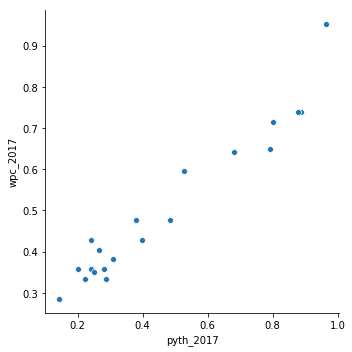

In [24]:
#Plot the data

sns.relplot(x="pyth_2017", y="wpc_2017", data =EPL_18)

In [22]:
# Run the regression

#pyth_lm = smf.ols(formula = 'wpc18 ~ pyth18', data=EPL2018).fit()
#pyth_lm.summary()

## Step 8 - 2017 Correlation matrix 

In [29]:
pyth_lm = smf.ols(formula = 'pyth_2017 ~ wpc_2017', data=EPL_18).fit()
pyth_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              pyth_2017   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     269.6
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.81e-12
Time:                        18:24:03   Log-Likelihood:                 26.010
No. Observations:                  20   AIC:                            -48.02
Df Residuals:                      18   BIC:                            -46.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2542      0.046     -5.496      0.000      -0.351      -0.157
wpc_2017       1.4309      0.087     16.420      0.000       1.248       1.614
==============================================================================
Omnibus:                        0.919   Durbin-Watson:                   2.222
Prob(Omnibus):                  0.632   Jarque-Bera (JB):                0.727
Skew:                          -0.431   Prob(JB):                        0.695
Kurtosis:                       2.639   Cond. No.                         7.05
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Step 9 - 2018 Correlation Matrix

In [30]:
pyth_lm_2 = smf.ols(formula = 'wpc_2017 ~ wpc_2018', data=EPL_18).fit()
pyth_lm_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               wpc_2017   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     24.10
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000113
Time:                        18:46:10   Log-Likelihood:                 14.605
No. Observations:                  20   AIC:                            -25.21
Df Residuals:                      18   BIC:                            -23.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0524      0.095      0.550      0.589      -0.148       0.252
wpc_2018       0.8967      0.183      4.909      0.000       0.513       1.280
==============================================================================
Omnibus:                        1.028   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.598   Jarque-Bera (JB):                0.768
Skew:                          -0.046   Prob(JB):                        0.681
Kurtosis:                       2.045   Cond. No.                         8.33
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Optional steps, not required for Assessment
### (Uncomment to run)

In [ ]:
#sns.relplot(x="pyth17", y="wpc18", data =Half2predictor)

In [ ]:
#sns.relplot(x="wpc17", y="wpc18", data =Half2predictor)

Now you have completed the assignment, are these results consistent with those we found for Major League Baseball?